## Análisis exploratorio de datos International Hotel Booking Analytics
**Analista:** LM Alicia Guadalupe Carballo Uicab  
**Fecha:** Mayo 2026  
**Prueba Técnica:** Analista de Datos

# Proceso:
1. Carga y exploración inicial 
2. Limpieza de datos
3. EDA univariado 
4. EDA bivariado
5. Gap Analysis 
6. Segmentación demografica
7. Alertas operativas 
8. conclusiones 



In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Estilo de grafica
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Librerías cargadas")

Librerías cargadas


In [ ]:
#carga y exploración de datos inicial 


# Ruta al archivo 
RUTA = r"C:\Users\alicecarballo\OneDrive\PENDIENTES\Prueba_Tecnica_Analista_Datos.xlsx"



# Carga de tablas
reviews = pd.read_excel(RUTA, sheet_name="reviews")
users   = pd.read_excel(RUTA, sheet_name="users")
hotels  = pd.read_excel(RUTA, sheet_name="hotels")

print("Datos cargados")
print(f"   reviews → {reviews.shape[0]:,} filas x {reviews.shape[1]} columnas")
print(f"   users   → {users.shape[0]:,} filas x {users.shape[1]} columnas")
print(f"   hotels  → {hotels.shape[0]:,} filas x {hotels.shape[1]} columnas")




Datos cargados
   reviews → 50,000 filas x 12 columnas
   users   → 2,000 filas x 6 columnas
   hotels  → 25 filas x 13 columnas


#1.1 Primeras filas de tablas

In [11]:
print("=== REVIEWS ===")
display(reviews.head(3))

print("\n=== USERS ===")
display(users.head(3))

print("\n=== HOTELS ===")
display(hotels.head(3))

=== REVIEWS ===


,review_id,user_id,hotel_id,review_date,score_overall,score_cleanliness,score_comfort,score_facilities,score_location,score_staff,score_value_for_money,review_text
0,1,1600,1,2022-10-07,8.7,8.6,8.7,8.5,9.0,8.8,8.7,Practice reduce young our because machine. Rec...
1,2,432,4,2020-03-24,9.1,10.0,9.1,9.0,8.6,9.4,8.6,Test cover traditional black. Process tell Mr ...
2,3,186,18,2023-12-18,8.8,9.7,8.8,8.3,8.7,8.1,8.6,Friend million student social study yeah. Grow...



=== USERS ===


,user_id,user_gender,country,age_group,traveller_type,join_date
0,1,Female,United Kingdom,35-44,Solo,2024-09-29
1,2,Male,United Kingdom,25-34,Solo,2023-11-29
2,3,Female,Mexico,25-34,Family,2022-04-03



=== HOTELS ===


,hotel_id,hotel_name,city,country,star_rating,lat,lon,cleanliness_base,comfort_base,facilities_base,location_base,staff_base,value_for_money_base
0,1,The Azure Tower,New York,United States,5,40.7580,-73.9855,9.1,8.8,8.9,9.5,8.6,8.0
1,2,The Royal Compass,London,United Kingdom,5,51.5072,-0.1276,9.0,9.2,8.8,9.4,9.0,7.9
2,3,L'Ã‰toile Palace,Paris,France,5,48.8566,2.3522,8.8,9.4,8.7,9.6,9.3,8.1


In [14]:
print("=== REVIEWS ===")
print(reviews.columns.tolist())

print("=== USERS ===")
print(users.columns.tolist())

print("=== HOTELS ===")
print(hotels.columns.tolist())



=== REVIEWS ===
['review_id', 'user_id', 'hotel_id', 'review_date', 'score_overall', 'score_cleanliness', 'score_comfort', 'score_facilities', 'score_location', 'score_staff', 'score_value_for_money', 'review_text']
=== USERS ===
['user_id', 'user_gender', 'country', 'age_group', 'traveller_type', 'join_date']
=== HOTELS ===
['hotel_id', 'hotel_name', 'city', 'country', 'star_rating', 'lat', 'lon', 'cleanliness_base', 'comfort_base', 'facilities_base', 'location_base', 'staff_base', 'value_for_money_base']


In [21]:
#verificacion de nulos 


for nombre, df in [("REVIEWS", reviews), ("USERS", users), ("HOTELS", hotels)]:
    print(f"\n{'='*50}")
    print(f"  {nombre}")
    print(f"{'='*50}")
    info = pd.DataFrame({
        "tipo"    : df.dtypes.astype(str),
        "nulos"   : df.isnull().sum(),
        "% nulos" : (df.isnull().mean() * 100).round(2),
        "únicos"  : df.nunique(),
    })
    display(info)


  REVIEWS


,tipo,nulos,% nulos,únicos
review_id,int64,0,0.0,50000
user_id,int64,0,0.0,2000
hotel_id,int64,0,0.0,25
review_date,datetime64[us],0,0.0,2192
score_overall,float64,0,0.0,15
score_cleanliness,float64,0,0.0,24
score_comfort,float64,0,0.0,22
score_facilities,float64,0,0.0,25
score_location,float64,0,0.0,22
score_staff,float64,0,0.0,22



  USERS


,tipo,nulos,% nulos,únicos
user_id,int64,0,0.0,2000
user_gender,str,0,0.0,3
country,str,0,0.0,25
age_group,str,0,0.0,5
traveller_type,str,0,0.0,4
join_date,datetime64[us],0,0.0,1200



  HOTELS


,tipo,nulos,% nulos,únicos
hotel_id,int64,0,0.0,25
hotel_name,str,0,0.0,25
city,str,0,0.0,25
country,str,0,0.0,25
star_rating,int64,0,0.0,1
lat,float64,0,0.0,25
lon,float64,0,0.0,25
cleanliness_base,float64,0,0.0,9
comfort_base,float64,0,0.0,10
facilities_base,float64,0,0.0,11


#Estadistica  descriptiva

In [22]:
print("=== SCORES de reviews (lo que opina el cliente) ===")
display(reviews.describe().round(2))

print("\n=== BASE SCORES (infraestructura del hotel) ===")
display(hotels.describe().round(2))

=== SCORES de reviews (lo que opina el cliente) ===


,review_id,user_id,hotel_id,review_date,score_overall,score_cleanliness,score_comfort,score_facilities,score_location,score_staff,score_value_for_money
count,50000.00,50000.00,50000.00,50000,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,25000.50,1005.57,13.05,2022-12-27 06:47:01.824000,8.94,9.05,9.02,8.74,9.18,8.97,8.43
min,1.00,1.00,1.00,2020-01-01 00:00:00,8.20,7.70,7.90,7.60,7.90,7.90,6.80
25%,12500.75,507.00,7.00,2021-06-27 00:00:00,8.80,8.70,8.70,8.40,8.90,8.70,8.10
50%,25000.50,1010.00,13.00,2022-12-27 00:00:00,8.90,9.10,9.00,8.70,9.20,9.00,8.50
75%,37500.25,1504.00,19.00,2024-06-28 00:00:00,9.10,9.40,9.30,9.10,9.50,9.20,8.80
max,50000.00,2000.00,25.00,2025-12-31 00:00:00,9.60,10.00,10.00,10.00,10.00,10.00,9.70
std,14433.90,576.71,7.20,NaN,0.18,0.50,0.42,0.50,0.42,0.40,0.53



=== BASE SCORES (infraestructura del hotel) ===


,hotel_id,star_rating,lat,lon,cleanliness_base,comfort_base,facilities_base,location_base,staff_base,value_for_money_base
count,25.00,25.0,25.00,25.00,25.00,25.00,25.00,25.00,25.00,25.00
mean,13.00,5.0,20.92,33.90,9.09,9.06,8.92,9.27,9.02,8.51
std,7.36,0.0,31.18,75.04,0.23,0.24,0.29,0.36,0.24,0.27
min,1.00,5.0,-41.29,-99.13,8.70,8.60,8.50,8.50,8.60,7.90
25%,7.00,5.0,6.52,2.17,8.90,8.90,8.70,9.00,8.80,8.40
50%,13.00,5.0,31.23,18.42,9.10,9.10,8.90,9.30,9.00,8.50
75%,19.00,5.0,41.90,100.50,9.30,9.20,9.10,9.60,9.20,8.70
max,25.00,5.0,55.76,174.78,9.60,9.50,9.60,9.80,9.50,8.90


### Nota metodológica  de Normalización
Se verificó que tanto los Base Scores (infraestructura) como los Review Scores 
(experiencia del cliente) están en la misma escala de **1 a 10**.

- Base scores: mín 1.0 — máx 10.0
- Review scores: mín 1.0 — máx 10.0

**Conclusión:** No se requiere normalización adicional. 
El Gap Analysis (review − base) es estadísticamente válido en escala original.

## Duplicados


In [23]:
for nombre, df, key in [
    ("reviews", reviews, "review_id"),
    ("users",   users,   "user_id"),
    ("hotels",  hotels,  "hotel_id"),
]:
    dups = df.duplicated(subset=key).sum()
    print(f"  {nombre}: {dups} duplicados en '{key}'")

  reviews: 0 duplicados en 'review_id'
  users: 0 duplicados en 'user_id'
  hotels: 0 duplicados en 'hotel_id'


### 2.2 Encoding roto en hotel_name

In [24]:
rotos = hotels[hotels['hotel_name'].str.contains('Ã', na=False)]['hotel_name']
print("Nombres con encoding roto:")
print(rotos.tolist())

Nombres con encoding roto:
["L'Ã‰toile Palace"]


### 2.3 Corrección de encoding

In [25]:
# Corregimos el encoding roto
hotels['hotel_name'] = (hotels['hotel_name']
    .str.replace('Ã‰', 'É', regex=False)
    .str.replace('Ã©', 'é', regex=False))

# Verificamos que quedó bien
print(hotels[hotels['hotel_name'].str.contains('toile')]['hotel_name'].tolist())

["L'Étoile Palace"]


### 2.4 Renombrar columnas ambiguas antes del merge

In [27]:
# Tanto users como hotels tienen columna 'country' las renombramos antes de los joins
users  = users.rename(columns={'country': 'user_country'})
hotels = hotels.rename(columns={'country': 'hotel_country'})

print("Columnas renombradas")
print(f"   users  → {users.columns.tolist()}")
print(f"   hotels → {hotels.columns.tolist()}")

Columnas renombradas
   users  → ['user_id', 'user_gender', 'user_country', 'age_group', 'traveller_type', 'join_date']
   hotels → ['hotel_id', 'hotel_name', 'city', 'hotel_country', 'star_rating', 'lat', 'lon', 'cleanliness_base', 'comfort_base', 'facilities_base', 'location_base', 'staff_base', 'value_for_money_base']


### 2.5 Verificar integridad referencial

###Esto verifica que no haya reseñas huérfanas — es decir, reviews que apunten a un hotel o usuario que no existe en las otras tablas. Si sale 0 en ambos, los joins van a funcionar perfectamente.

In [28]:
# Verificamos que todos los IDs en reviews existan en sus tablas correspondientes
hotel_ids_rev = set(reviews['hotel_id'].unique())
hotel_ids_hot = set(hotels['hotel_id'].unique())
user_ids_rev  = set(reviews['user_id'].unique())
user_ids_usr  = set(users['user_id'].unique())

print(f"IDs de hotel en reviews sin match en hotels: {len(hotel_ids_rev - hotel_ids_hot)}")
print(f"IDs de usuario en reviews sin match en users: {len(user_ids_rev - user_ids_usr)}")

IDs de hotel en reviews sin match en hotels: 0
IDs de usuario en reviews sin match en users: 0


### 2.6 Parsear fechas y extraer componentes

In [29]:
# Extraemos año, mes y trimestre para análisis temporal
reviews['review_date'] = pd.to_datetime(reviews['review_date'])
reviews['año']  = reviews['review_date'].dt.year
reviews['mes']  = reviews['review_date'].dt.month
reviews['trim'] = reviews['review_date'].dt.quarter

users['join_date'] = pd.to_datetime(users['join_date'])

print("Fechas procesadas")
print(f"   Reviews van de {reviews['review_date'].min().date()} a {reviews['review_date'].max().date()}")

Fechas procesadas
   Reviews van de 2020-01-01 a 2025-12-31


### 2.7 Resumen de limpieza

In [30]:
print("RESUMEN DE LIMPIEZA")
print("="*45)
print(f"  reviews → {reviews.shape[0]:,} filas, {reviews.isnull().sum().sum()} nulos")
print(f"  users   → {users.shape[0]:,} filas, {users.isnull().sum().sum()} nulos")
print(f"  hotels  → {hotels.shape[0]:,} filas, {hotels.isnull().sum().sum()} nulos")
print()
print("  Problemas encontrados y resueltos:")
print("  Sin duplicados en ninguna tabla")
print("  Sin nulos en ninguna tabla")
print("  Encoding corregido: L'Étoile Palace")
print("  Columnas 'country' renombradas para evitar colisión")
print("  Integridad referencial verificada — 0 IDs huérfanos")
print("  Escalas verificadas: ambas en rango 1–10, no requiere normalización")

RESUMEN DE LIMPIEZA
  reviews → 50,000 filas, 0 nulos
  users   → 2,000 filas, 0 nulos
  hotels  → 25 filas, 0 nulos

  Problemas encontrados y resueltos:
  Sin duplicados en ninguna tabla
  Sin nulos en ninguna tabla
  Encoding corregido: L'Étoile Palace
  Columnas 'country' renombradas para evitar colisión
  Integridad referencial verificada — 0 IDs huérfanos
  Escalas verificadas: ambas en rango 1–10, no requiere normalización


## 3. EDA Univariado
### 3.1 Distribución de review scores

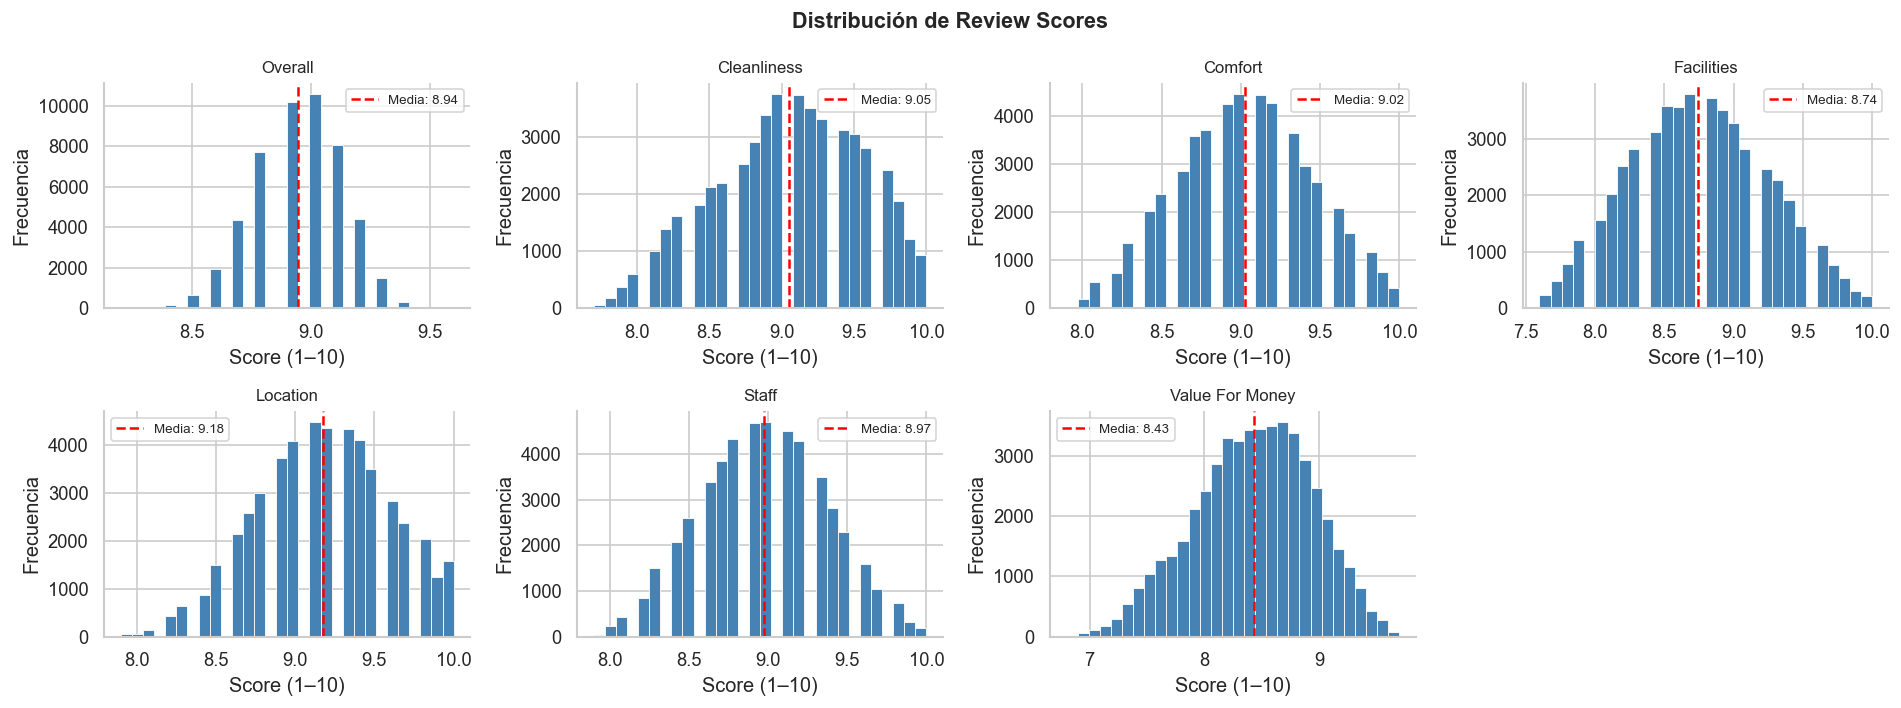

In [31]:
score_cols = ['score_overall', 'score_cleanliness', 'score_comfort',
              'score_facilities', 'score_location', 'score_staff', 
              'score_value_for_money']

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for i, col in enumerate(score_cols):
    ax = axes[i]
    ax.hist(reviews[col], bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.axvline(reviews[col].mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Media: {reviews[col].mean():.2f}')
    ax.set_title(col.replace('score_', '').replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('Score (1–10)')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle('Distribución de Review Scores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Hallazgo 3.1:** Las distribuciones están sesgadas hacia scores altos (media ~9.0).

Value for Money es la dimensión más crítica con la media más baja (8.43) y mayor dispersión.

En un contexto de scores altos, cualquier desviación negativa es significativa.

### 3.2 Variables categóricas — usuarios

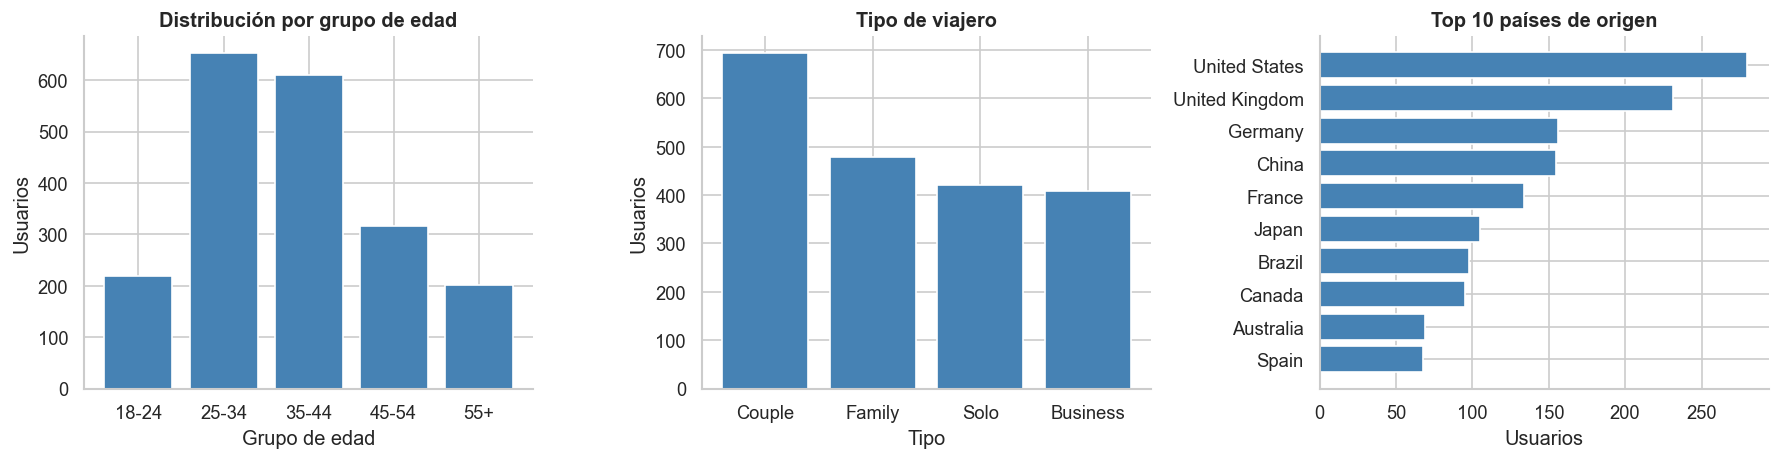

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Grupo de edad
age_order = ['18-24', '25-34', '35-44', '45-54', '55+']
cnt1 = users['age_group'].value_counts().reindex(age_order)
axes[0].bar(cnt1.index, cnt1.values, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución por grupo de edad', fontweight='bold')
axes[0].set_xlabel('Grupo de edad')
axes[0].set_ylabel('Usuarios')

# Tipo de viajero
cnt2 = users['traveller_type'].value_counts()
axes[1].bar(cnt2.index, cnt2.values, color='steelblue', edgecolor='white')
axes[1].set_title('Tipo de viajero', fontweight='bold')
axes[1].set_xlabel('Tipo')
axes[1].set_ylabel('Usuarios')

# Top 10 países
cnt3 = users['user_country'].value_counts().head(10)
axes[2].barh(cnt3.index[::-1], cnt3.values[::-1], color='steelblue')
axes[2].set_title('Top 10 países de origen', fontweight='bold')
axes[2].set_xlabel('Usuarios')

plt.tight_layout()
plt.show()

**Hallazgo 3.2:** El perfil de usuario más frecuente es:
- Edad: 25–34 años

- Tipo de viajero: Couple 

- País de origen: Estados Unidos

Importante: este es el segmento más común, pero NO necesariamente el más crítico en satisfacción — eso lo veremos en la segmentación demográfica.

### 3.3 Distribución de base scores (infraestructura)

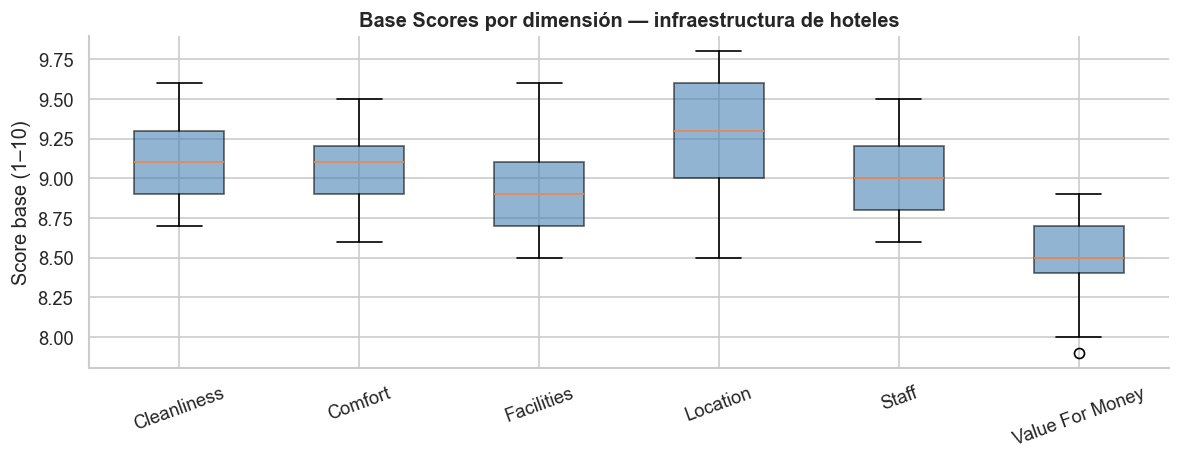

In [33]:
base_cols = ['cleanliness_base', 'comfort_base', 'facilities_base',
             'location_base', 'staff_base', 'value_for_money_base']

fig, ax = plt.subplots(figsize=(10, 4))

data_box = [hotels[c].values for c in base_cols]
labels   = [c.replace('_base', '').replace('_', ' ').title() for c in base_cols]

bp = ax.boxplot(data_box, patch_artist=True, labels=labels)

# Colorear las cajas
colors_box = ['steelblue'] * len(base_cols)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.6)

ax.set_title('Base Scores por dimensión — infraestructura de hoteles', fontweight='bold')
ax.set_ylabel('Score base (1–10)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

**Hallazgo 3.3:** 
- Location tiene los base scores más altos y consistentes: los hoteles están bien ubicados.

- Value for Money tiene los scores más bajos en infraestructura, consistente con lo visto en reviews (media 8.43).

- Patrón repetido en dos fuentes distintas = hallazgo confiable.

### 3.4 Volumen de reviews por hotel y evolución temporal

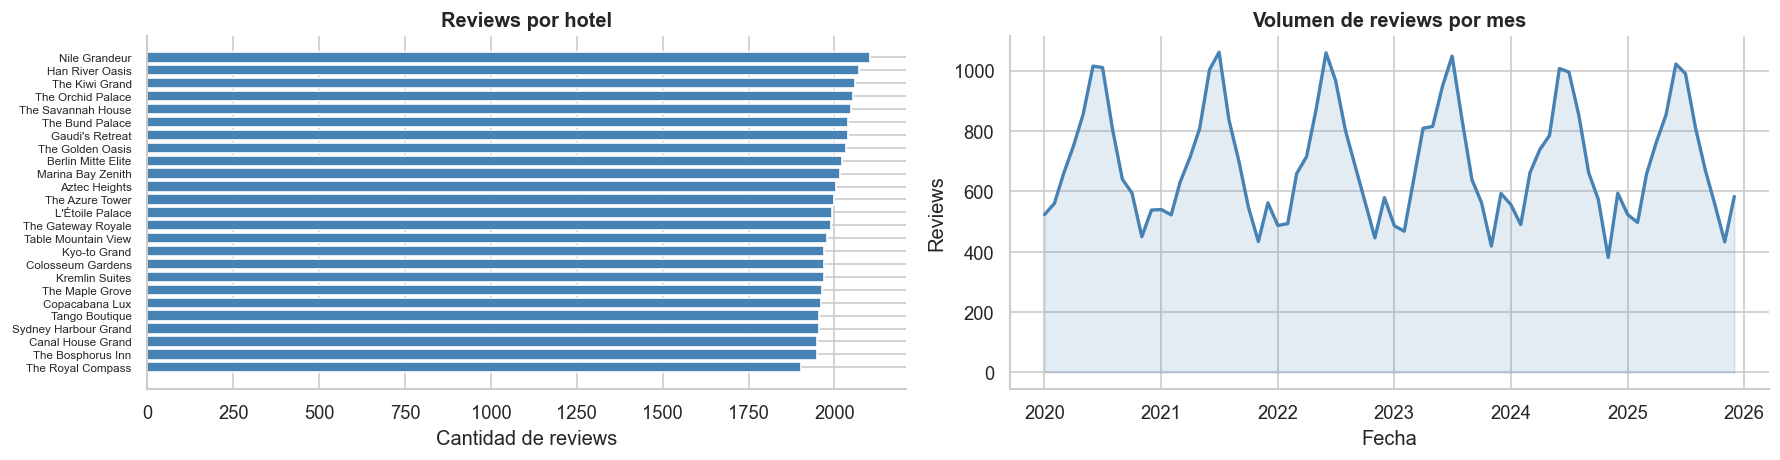

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Volumen por hotel
vol = reviews.groupby('hotel_id').size().reset_index(name='n')
vol = vol.merge(hotels[['hotel_id', 'hotel_name']], on='hotel_id').sort_values('n')

axes[0].barh(vol['hotel_name'], vol['n'], color='steelblue')
axes[0].set_title('Reviews por hotel', fontweight='bold')
axes[0].set_xlabel('Cantidad de reviews')
axes[0].tick_params(axis='y', labelsize=7)

# Evolución temporal mensual
evol = reviews.groupby(reviews['review_date'].dt.to_period('M')).size().reset_index(name='n')
evol['fecha'] = evol['review_date'].dt.to_timestamp()
evol = evol.sort_values('fecha')

axes[1].plot(evol['fecha'], evol['n'], color='steelblue', linewidth=2)
axes[1].fill_between(evol['fecha'], evol['n'], alpha=0.15, color='steelblue')
axes[1].set_title('Volumen de reviews por mes', fontweight='bold')
axes[1].set_ylabel('Reviews')
axes[1].set_xlabel('Fecha')

plt.tight_layout()
plt.show()

**Hallazgo 3.4:**
- Volumen de reviews uniforme entre hoteles — análisis sin sesgo por volumen. Excepción: The Royal Compass con menor volumen, interpretar con cautela.

- Evolución temporal muestra estacionalidad anual clara — picos repetidos en los mismos meses cada año. Oportunidad para anticipar capacidad operativa en temporada alta.

## 4. EDA Bivariado y Correlaciones
### 4.1 Merge de las tres tablas

In [36]:
df = (reviews
      .merge(hotels, on='hotel_id')
      .merge(users,  on='user_id'))

print(f"Dataset unificado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"   Columnas: {df.columns.tolist()}")

Dataset unificado: 50,000 filas × 32 columnas
   Columnas: ['review_id', 'user_id', 'hotel_id', 'review_date', 'score_overall', 'score_cleanliness', 'score_comfort', 'score_facilities', 'score_location', 'score_staff', 'score_value_for_money', 'review_text', 'año', 'mes', 'trim', 'hotel_name', 'city', 'hotel_country', 'star_rating', 'lat', 'lon', 'cleanliness_base', 'comfort_base', 'facilities_base', 'location_base', 'staff_base', 'value_for_money_base', 'user_gender', 'user_country', 'age_group', 'traveller_type', 'join_date']


### 4.2 Correlación entre dimensiones de score

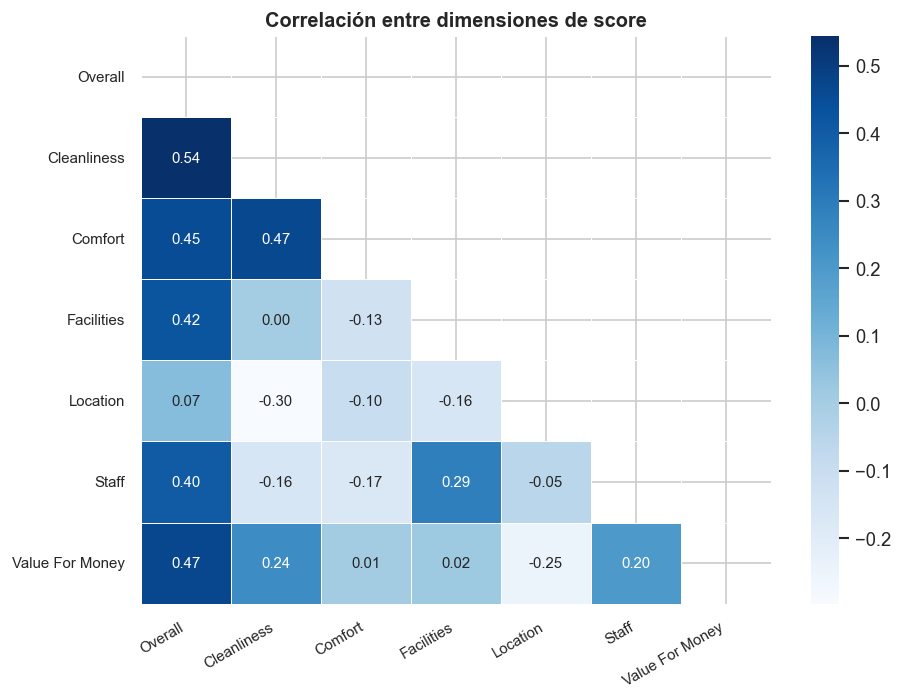

In [37]:
score_cols = ['score_overall', 'score_cleanliness', 'score_comfort',
              'score_facilities', 'score_location', 'score_staff', 
              'score_value_for_money']

corr = df[score_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))  # oculta triángulo superior
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, annot_kws={'size': 9})

labels = [c.replace('score_', '').replace('_', ' ').title() for c in corr.columns]
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(labels, rotation=0, fontsize=9)
ax.set_title('Correlación entre dimensiones de score', fontweight='bold')
plt.tight_layout()
plt.show()

### La matriz anterior no muestra claro el overall por lo que ajustamos

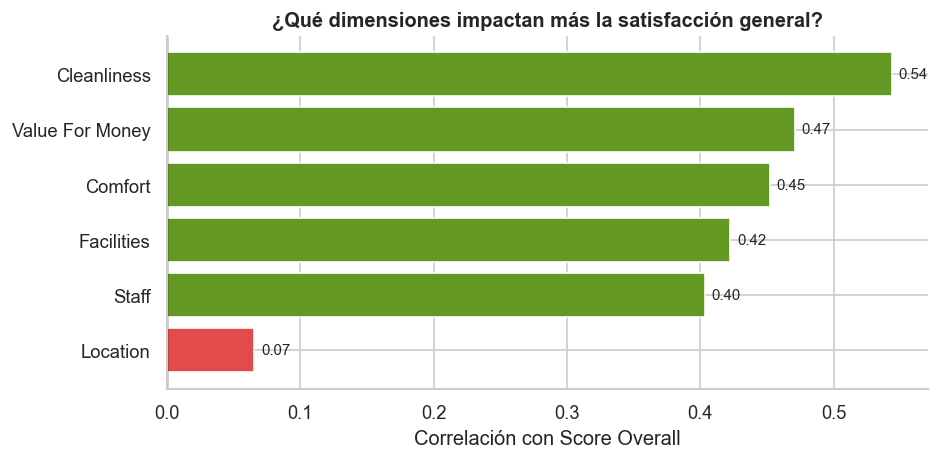

In [38]:
# Correlación de cada dimensión contra score_overall
corr_overall = df[score_cols].corr()['score_overall'].drop('score_overall').sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colores = ['#E24B4A' if v < 0.2 else '#EF9F27' if v < 0.4 else '#639922' 
           for v in corr_overall.values]

bars = ax.barh(
    [c.replace('score_', '').replace('_', ' ').title() for c in corr_overall.index],
    corr_overall.values,
    color=colores, edgecolor='white'
)

# Etiquetas en cada barra
for bar, val in zip(bars, corr_overall.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

ax.set_xlabel('Correlación con Score Overall')
ax.set_title('¿Qué dimensiones impactan más la satisfacción general?', fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

**Hallazgo 4.2:** Cleanliness (0.54) y Value for Money (0.47) son los principales predictores del score overall.
Location casi no influye (0.07) a pesar de tener buenos base scores el cliente da por sentada la ubicación pero castiga fuertemente  la limpieza y el precio.

### 4.3 Score Overall vs Staff y por categoría estelar

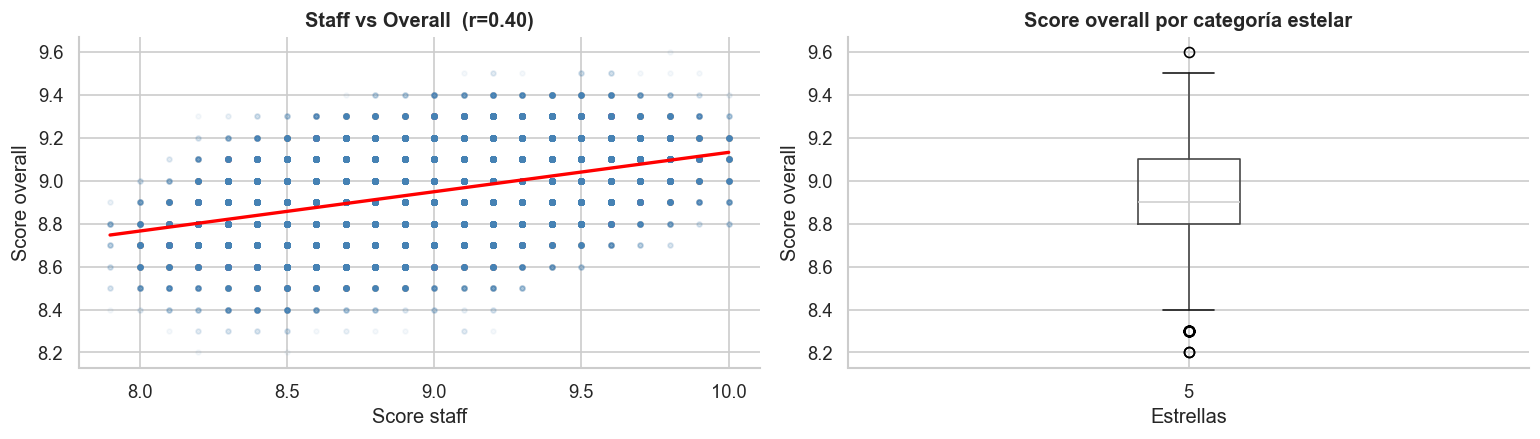

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scatter Staff vs Overall
axes[0].scatter(df['score_staff'], df['score_overall'],
                alpha=0.05, s=8, color='steelblue')
m, b = np.polyfit(df['score_staff'], df['score_overall'], 1)
x_line = np.linspace(df['score_staff'].min(), df['score_staff'].max(), 100)
axes[0].plot(x_line, m*x_line + b, color='red', linewidth=2)
r, p = stats.pearsonr(df['score_staff'], df['score_overall'])
axes[0].set_title(f'Staff vs Overall  (r={r:.2f})', fontweight='bold')
axes[0].set_xlabel('Score staff')
axes[0].set_ylabel('Score overall')

# Boxplot Overall por star rating
df.boxplot(column='score_overall', by='star_rating', ax=axes[1])
axes[1].set_title('Score overall por categoría estelar', fontweight='bold')
axes[1].set_xlabel('Estrellas')
axes[1].set_ylabel('Score overall')
plt.suptitle('')
plt.tight_layout()
plt.show()

**Hallazgo 4.3:** 
- Todos los hoteles son 5 estrellas, no es posible segmentar por categoría estelar. El benchmark de comparación debe ser interno entre hoteles, no por categoría.
- Staff tiene correlación positiva con Overall (r=0.40) pero con alta dispersión — mejorar el staff ayuda pero no es suficiente por sí solo.

## 5. Gap Analysis Infraestructura vs Experiencia del cliente

### 5.1 Definición y cálculo del gap

**Gap = Score_review − Score_base**
- Negativo: la infraestructura supera lo que el cliente experimenta (falla operativa)

- Positivo: el servicio supera las expectativas de la infraestructura (operación eficiente)

- Escala válida: ambas en 1–10, confirmado en EDA — no requiere normalización

In [41]:
DIMS = ['cleanliness', 'comfort', 'facilities', 
        'location', 'staff', 'value_for_money']

# Calculamos el gap por cada dimensión
for d in DIMS:
    df[f'gap_{d}'] = df[f'score_{d}'] - df[f'{d}_base']

# Gap promedio global
gap_cols = [f'gap_{d}' for d in DIMS]
df['gap_overall'] = df[gap_cols].mean(axis=1)

print("Gaps calculados")
print("\nGap promedio por dimensión (toda la cadena):")
for d in DIMS:
    media = df[f'gap_{d}'].mean()
    print(f"  {d:20s} → {media:+.3f}")

print(f"\n  {'GLOBAL':20s} → {df['gap_overall'].mean():+.3f}")

Gaps calculados

Gap promedio por dimensión (toda la cadena):
  cleanliness          → -0.039
  comfort              → -0.040
  facilities           → -0.174
  location             → -0.094
  staff                → -0.044
  value_for_money      → -0.079

  GLOBAL               → -0.078


**Hallazgo 5.1:**
- Facilities tiene el gap más negativo (−0.174) es decir, la infraestructura física no cumple las expectativas del cliente en todas las propiedades.

- Location tiene gap de −0.094 a pesar de tener buenos base scores por lo que los clientes esperan aún más de ubicaciones premium.

- Gap global de −0.078 indica que en promedio la experiencia del cliente, está por debajo de lo que la infraestructura prometía.

> Priorizar inversión en remodelación (facilities)  
> antes que capacitación (staff gap solo −0.044).

### 5.2 Gap por hotel — heatmap

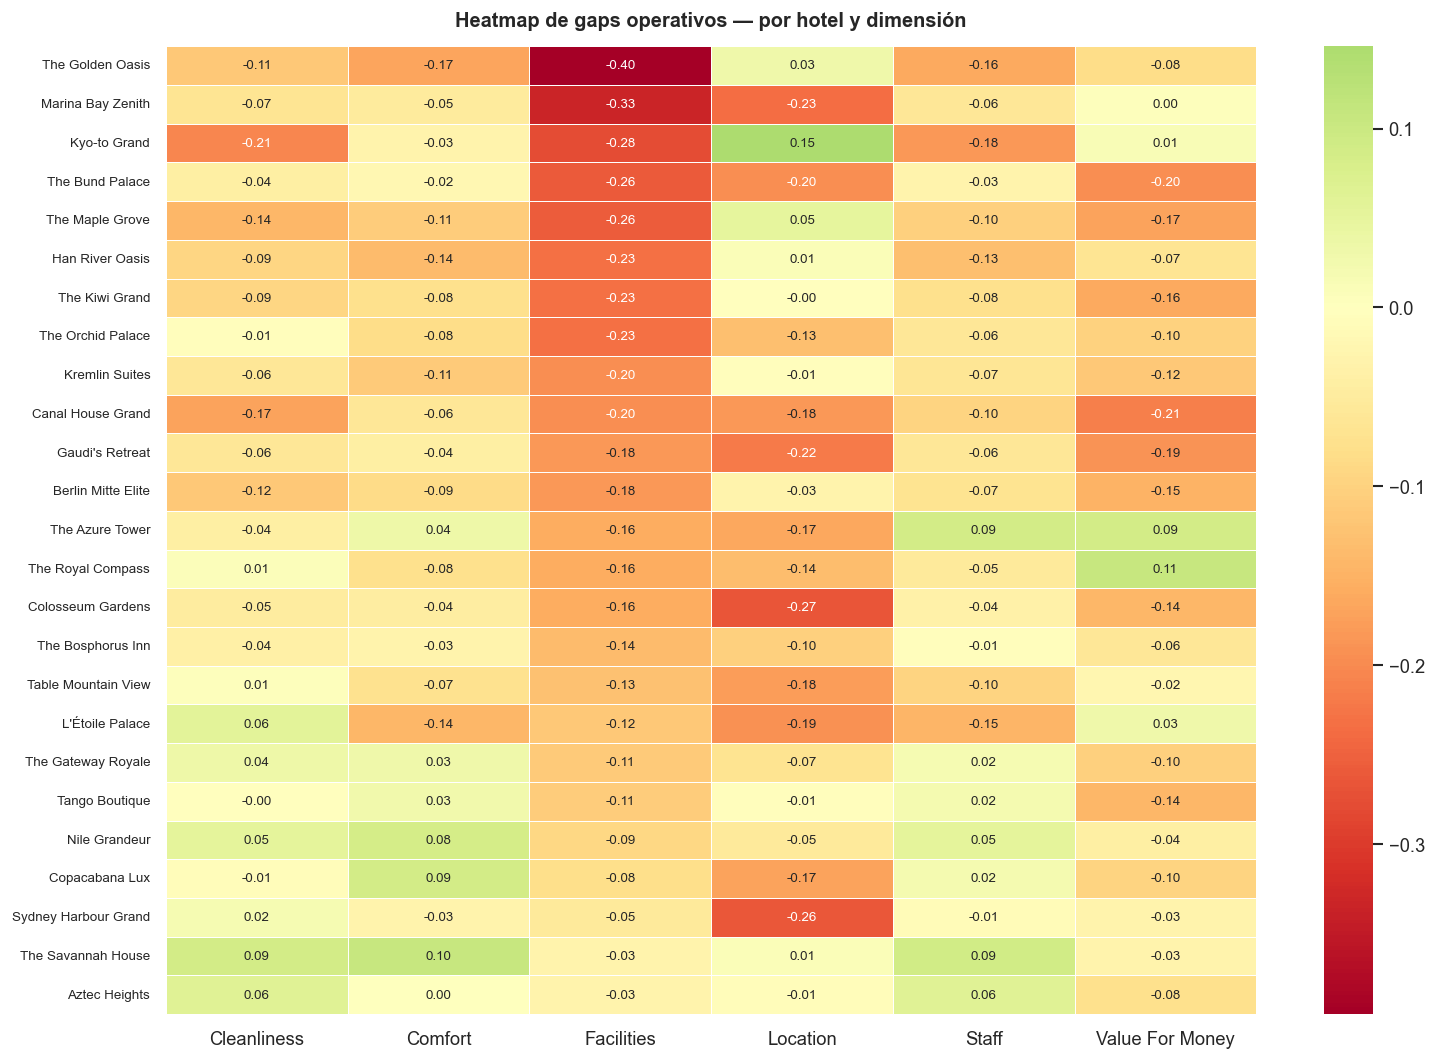

In [42]:
# Gap promedio por hotel
hotel_gap = (df.groupby(['hotel_id', 'hotel_name', 'city'])
               [gap_cols + ['gap_overall']]
               .mean()
               .round(3)
               .reset_index()
               .sort_values('gap_overall'))

fig, ax = plt.subplots(figsize=(13, 9))

hm_data = hotel_gap.set_index('hotel_name')[gap_cols]
hm_data.columns = [c.replace('gap_', '').replace('_', ' ').title() 
                   for c in hm_data.columns]
hm_data = hm_data.sort_values('Facilities')

sns.heatmap(hm_data, annot=True, fmt='.2f', center=0,
            cmap='RdYlGn', linewidths=0.5, ax=ax,
            annot_kws={'size': 8})

ax.set_title('Heatmap de gaps operativos — por hotel y dimensión', 
             fontweight='bold', pad=12)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

**Hallazgo 5.2:**
- Facilities es rojo en prácticamente todos los hoteles podemos decir que el problema es sistémico 
  de la cadena, no de un hotel individual.

- The Golden Oasis tiene el gap más crítico en facilities (−0.40) lo que lo hace candidato prioritario para remodelación.

- Cleanliness y Staff son relativamente verdes  no requieren una inversión urgente.

### 5.3 Ranking de hoteles por gap global

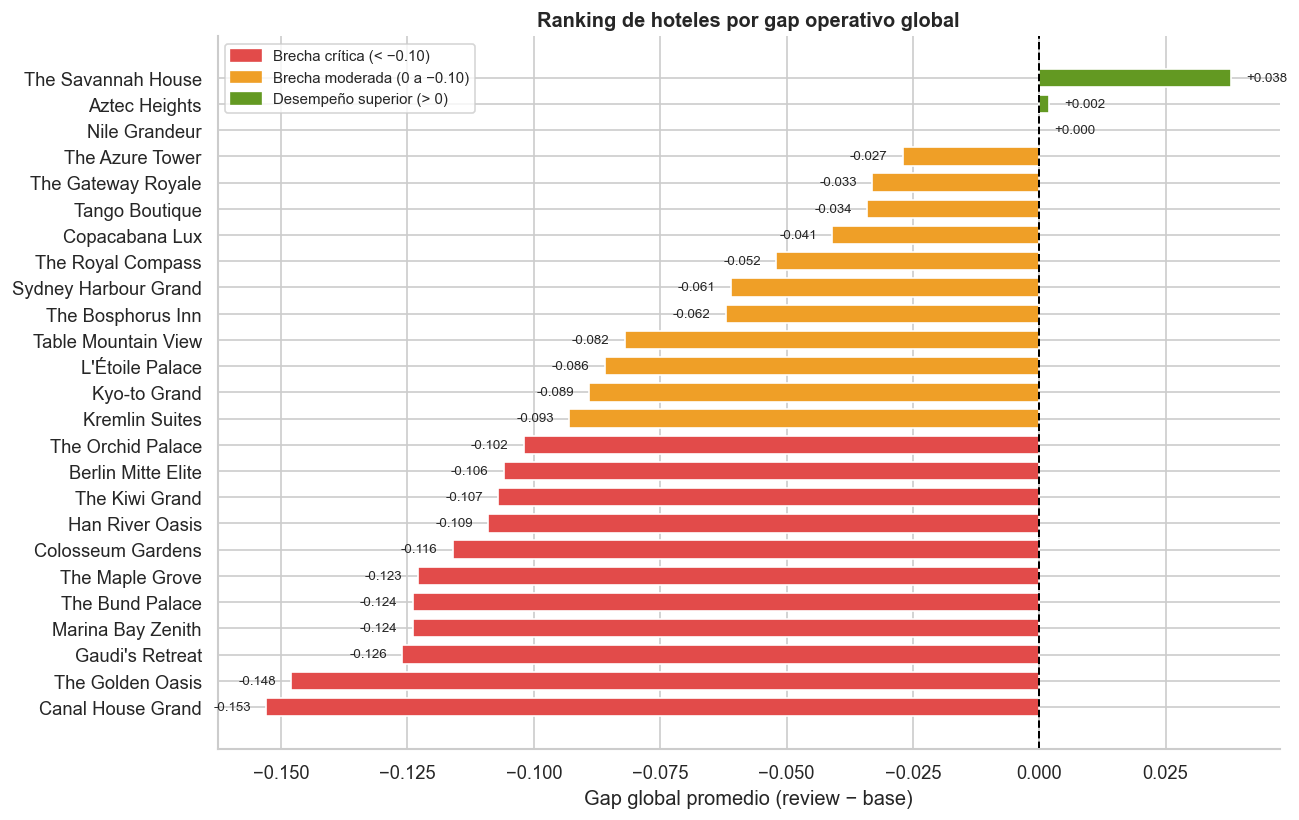

In [43]:
fig, ax = plt.subplots(figsize=(11, 7))

colores = ['#E24B4A' if v < -0.10 else '#EF9F27' if v < 0 else '#639922'
           for v in hotel_gap['gap_overall']]

bars = ax.barh(hotel_gap['hotel_name'], hotel_gap['gap_overall'],
               color=colores, edgecolor='white', height=0.7)

ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel('Gap global promedio (review − base)')
ax.set_title('Ranking de hoteles por gap operativo global', fontweight='bold')

# Etiquetas
for bar, val in zip(bars, hotel_gap['gap_overall']):
    ax.text(val + 0.003 if val >= 0 else val - 0.003,
            bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8)

from matplotlib.patches import Patch
legend = [
    Patch(color='#E24B4A', label='Brecha crítica (< −0.10)'),
    Patch(color='#EF9F27', label='Brecha moderada (0 a −0.10)'),
    Patch(color='#639922', label='Desempeño superior (> 0)'),
]
ax.legend(handles=legend, fontsize=9)
plt.tight_layout()
plt.show()

**Hallazgo 5.3:**
- 12 de 25 hoteles tienen brecha crítica (< −0.10) — casi la mitad de la cadena.
- Canal House Grand (−0.153) y The Golden Oasis (−0.148) son prioridad máxima.
- Solo 3 hoteles superan su propia infraestructura: The Savannah House (+0.038),
  Aztec Heights (+0.002) y Nile Grandeur (0.000).
- The Savannah House es el benchmark interno — estudiar su modelo operativo
  para replicarlo en los hoteles críticos.

## 6. Segmentación Demográfica
### 6.1 Gap por tipo de viajero

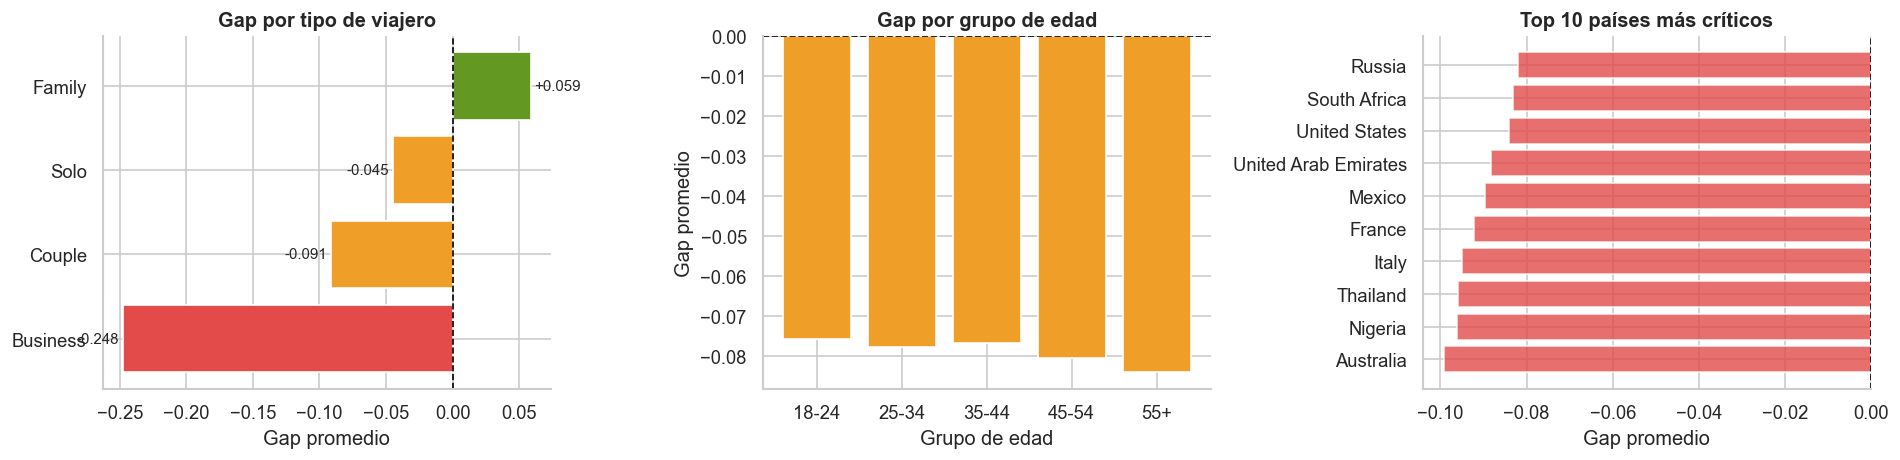

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Por tipo de viajero
seg_trav = df.groupby('traveller_type')['gap_overall'].mean().sort_values()
colores_t = ['#E24B4A' if v < -0.15 else '#EF9F27' if v < 0 else '#639922'
             for v in seg_trav.values]

axes[0].barh(seg_trav.index, seg_trav.values, color=colores_t, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Gap por tipo de viajero', fontweight='bold')
axes[0].set_xlabel('Gap promedio')
for i, (idx, val) in enumerate(seg_trav.items()):
    axes[0].text(val - 0.003 if val < 0 else val + 0.003, i,
                 f'{val:+.3f}', va='center',
                 ha='right' if val < 0 else 'left', fontsize=9)

# Por grupo de edad
age_order = ['18-24', '25-34', '35-44', '45-54', '55+']
seg_age = df.groupby('age_group')['gap_overall'].mean().reindex(age_order)
axes[1].bar(seg_age.index, seg_age.values, color='#EF9F27', edgecolor='white')
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('Gap por grupo de edad', fontweight='bold')
axes[1].set_ylabel('Gap promedio')
axes[1].set_xlabel('Grupo de edad')

# Top 10 países más críticos
seg_pais = df.groupby('user_country')['gap_overall'].mean().sort_values().head(10)
axes[2].barh(seg_pais.index, seg_pais.values, color='#E24B4A', alpha=0.8, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=1, linestyle='--')
axes[2].set_title('Top 10 países más críticos', fontweight='bold')
axes[2].set_xlabel('Gap promedio')

plt.tight_layout()
plt.show()

### 6.2 Cruce tipo de viajero por dimensión

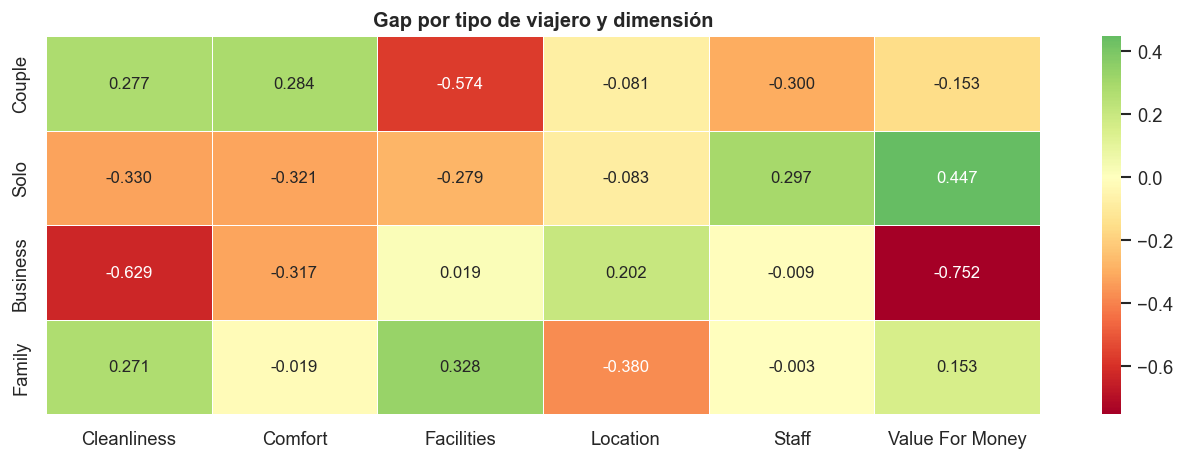

In [45]:
gap_cols = [f'gap_{d}' for d in DIMS]

pivot = df.groupby('traveller_type')[gap_cols].mean().round(3)
pivot.columns = [c.replace('gap_', '').replace('_', ' ').title() 
                 for c in pivot.columns]
pivot = pivot.sort_values('Facilities')

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(pivot, annot=True, fmt='.3f', center=0,
            cmap='RdYlGn', linewidths=0.5, ax=ax,
            annot_kws={'size': 10})
ax.set_title('Gap por tipo de viajero y dimensión', fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

#Ejemplo de calculo de cada gap 

In [47]:
# Veamos un ejemplo real
ejemplo = df[df['traveller_type'] == 'Business'][['hotel_name', 
    'score_cleanliness', 'cleanliness_base', 'gap_cleanliness']].head(10)
display(ejemplo)

,hotel_name,score_cleanliness,cleanliness_base,gap_cleanliness
3,Gaudi's Retreat,9.0,9.2,-0.2
6,Tango Boutique,8.1,8.9,-0.8
7,Marina Bay Zenith,8.1,9.2,-1.1
11,Nile Grandeur,8.7,8.8,-0.1
12,Nile Grandeur,8.6,8.8,-0.2
16,The Azure Tower,8.3,9.1,-0.8
25,Kyo-to Grand,8.9,9.6,-0.7
28,The Orchid Palace,8.7,9.0,-0.3
33,Aztec Heights,8.3,8.7,-0.4
43,The Golden Oasis,8.3,9.3,-1.0


**Hallazgo 6.3 CRÍTICO:**
- Business + Value for Money = −0.752 El gap más grande de todo el análisis.

- Los viajeros de negocios sienten que el precio no justifica la experiencia.

- Riesgo alto: son clientes frecuentes con poder de decisión sobre  qué hotel usa toda su empresa. Perder un cliente Business puede significar perder la cuenta corporativa completa.

In [48]:
resultado = df[df['traveller_type'] == 'Business']['gap_value_for_money'].mean()
print(f"Gap promedio Business + Value for Money: {resultado:.3f}")

Gap promedio Business + Value for Money: -0.752


## 7. Alertas Operativas
### 7.1 Hoteles bajo el benchmark de la cadena

In [49]:
# Benchmark promedio de toda la cadena
benchmark = df[['score_staff', 'score_cleanliness', 'score_facilities']].mean()

# Score promedio por hotel
hotel_scores = (df.groupby(['hotel_id', 'hotel_name', 'city'])
                  [['score_staff', 'score_cleanliness', 
                    'score_facilities', 'gap_overall']]
                  .mean()
                  .reset_index())

# Comparar contra benchmark
hotel_scores['alerta_staff']  = hotel_scores['score_staff']        < benchmark['score_staff']
hotel_scores['alerta_clean']  = hotel_scores['score_cleanliness']  < benchmark['score_cleanliness']
hotel_scores['alerta_facil']  = hotel_scores['score_facilities']   < benchmark['score_facilities']
hotel_scores['n_alertas']     = (hotel_scores[['alerta_staff', 
                                               'alerta_clean', 
                                               'alerta_facil']]
                                  .sum(axis=1))

alertas = hotel_scores[hotel_scores['n_alertas'] > 0].sort_values('n_alertas', ascending=False)
print(f"Hoteles con al menos 1 alerta: {len(alertas)} de {len(hotel_scores)}")
display(alertas[['hotel_name', 'city', 'score_staff', 'score_cleanliness', 
                 'score_facilities', 'gap_overall', 
                 'alerta_staff', 'alerta_clean', 'alerta_facil', 'n_alertas']])

Hoteles con al menos 1 alerta: 17 de 25


,hotel_name,city,score_staff,score_cleanliness,score_facilities,gap_overall,alerta_staff,alerta_clean,alerta_facil,n_alertas
1,The Royal Compass,London,8.947213,9.007571,8.640852,-0.051551,True,True,True,3
12,The Gateway Royale,Mumbai,8.817798,8.936149,8.587984,-0.032713,True,True,True,3
6,Sydney Harbour Grand,Sydney,8.888792,8.920010,8.446776,-0.060764,True,True,True,3
7,Copacabana Lux,Rio de Janeiro,8.822375,8.989908,8.519725,-0.041420,True,True,True,3
11,Aztec Heights,Mexico City,8.763323,8.762525,8.472455,0.002462,True,True,True,3
23,The Savannah House,Lagos,8.690678,8.786384,8.468765,0.038409,True,True,True,3
22,Tango Boutique,Buenos Aires,8.822751,8.899642,8.591309,-0.034083,True,True,True,3
17,Nile Grandeur,Cairo,8.751568,8.853137,8.508508,0.000055,True,True,True,3
0,The Azure Tower,New York,8.684935,9.057007,8.739890,-0.026518,True,False,True,2
20,The Bosphorus Inn,Istanbul,8.894559,9.061550,8.660524,-0.062346,True,False,True,2


**Hallazgo 7.1:**
- 17 de 25 hoteles (68%) tienen al menos una alerta operativa.

- No es un problema de hoteles individuales — es un problema de la cadena completa.

- Requiere intervención a nivel corporativo, no solo hotel por hotel.

### 7.2 Mapa de alertas

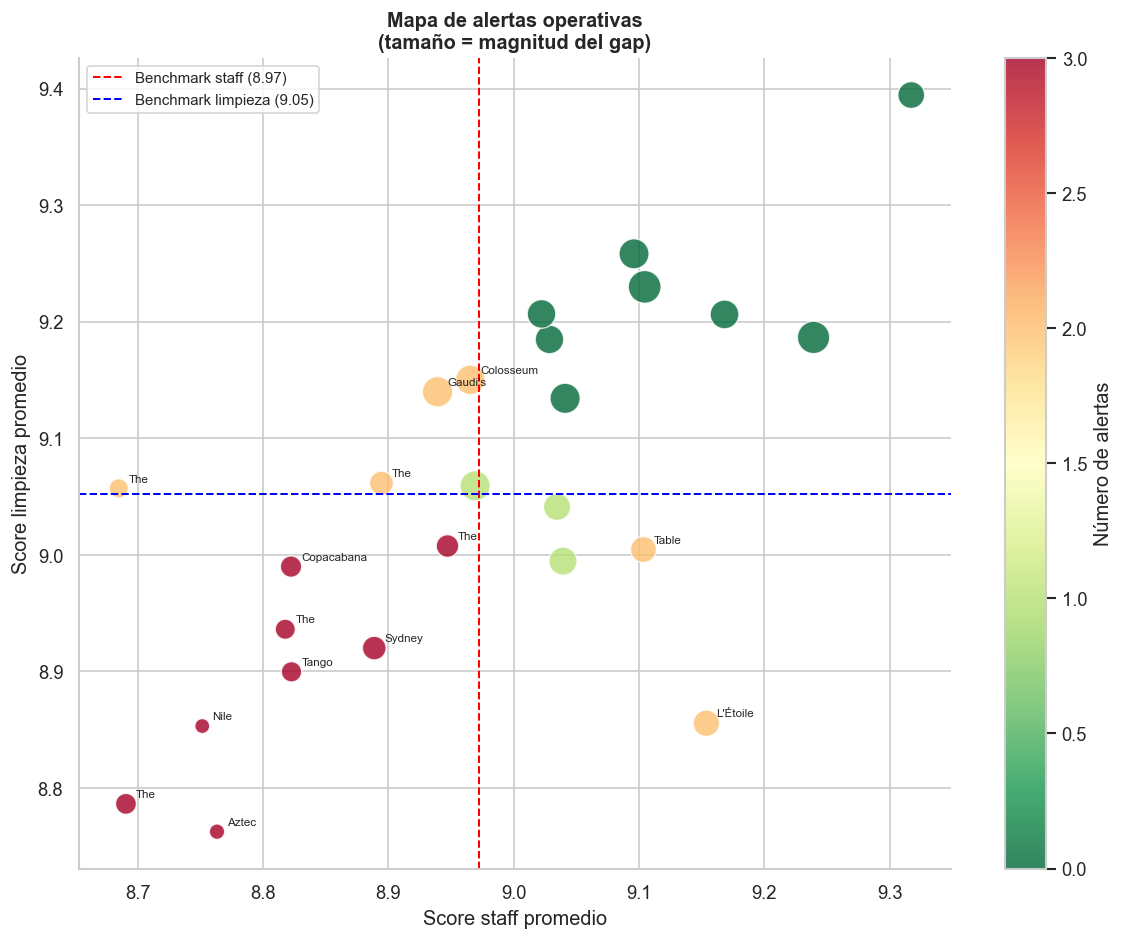

In [50]:
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    hotel_scores['score_staff'],
    hotel_scores['score_cleanliness'],
    c=hotel_scores['n_alertas'],
    cmap='RdYlGn_r',
    s=hotel_scores['gap_overall'].abs() * 2000 + 80,
    alpha=0.8, edgecolors='white', linewidths=0.8,
    vmin=0, vmax=3
)

# Líneas de benchmark
ax.axvline(benchmark['score_staff'], color='red', linestyle='--', 
           linewidth=1.2, label=f"Benchmark staff ({benchmark['score_staff']:.2f})")
ax.axhline(benchmark['score_cleanliness'], color='blue', linestyle='--',
           linewidth=1.2, label=f"Benchmark limpieza ({benchmark['score_cleanliness']:.2f})")

# Etiquetas hoteles con 2+ alertas
for _, row in hotel_scores[hotel_scores['n_alertas'] >= 2].iterrows():
    ax.annotate(row['hotel_name'].split()[0],
                (row['score_staff'], row['score_cleanliness']),
                textcoords='offset points', xytext=(6, 4), fontsize=7)

plt.colorbar(scatter, label='Número de alertas')
ax.set_xlabel('Score staff promedio')
ax.set_ylabel('Score limpieza promedio')
ax.set_title('Mapa de alertas operativas\n(tamaño = magnitud del gap)', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Arreglo de etiquetas

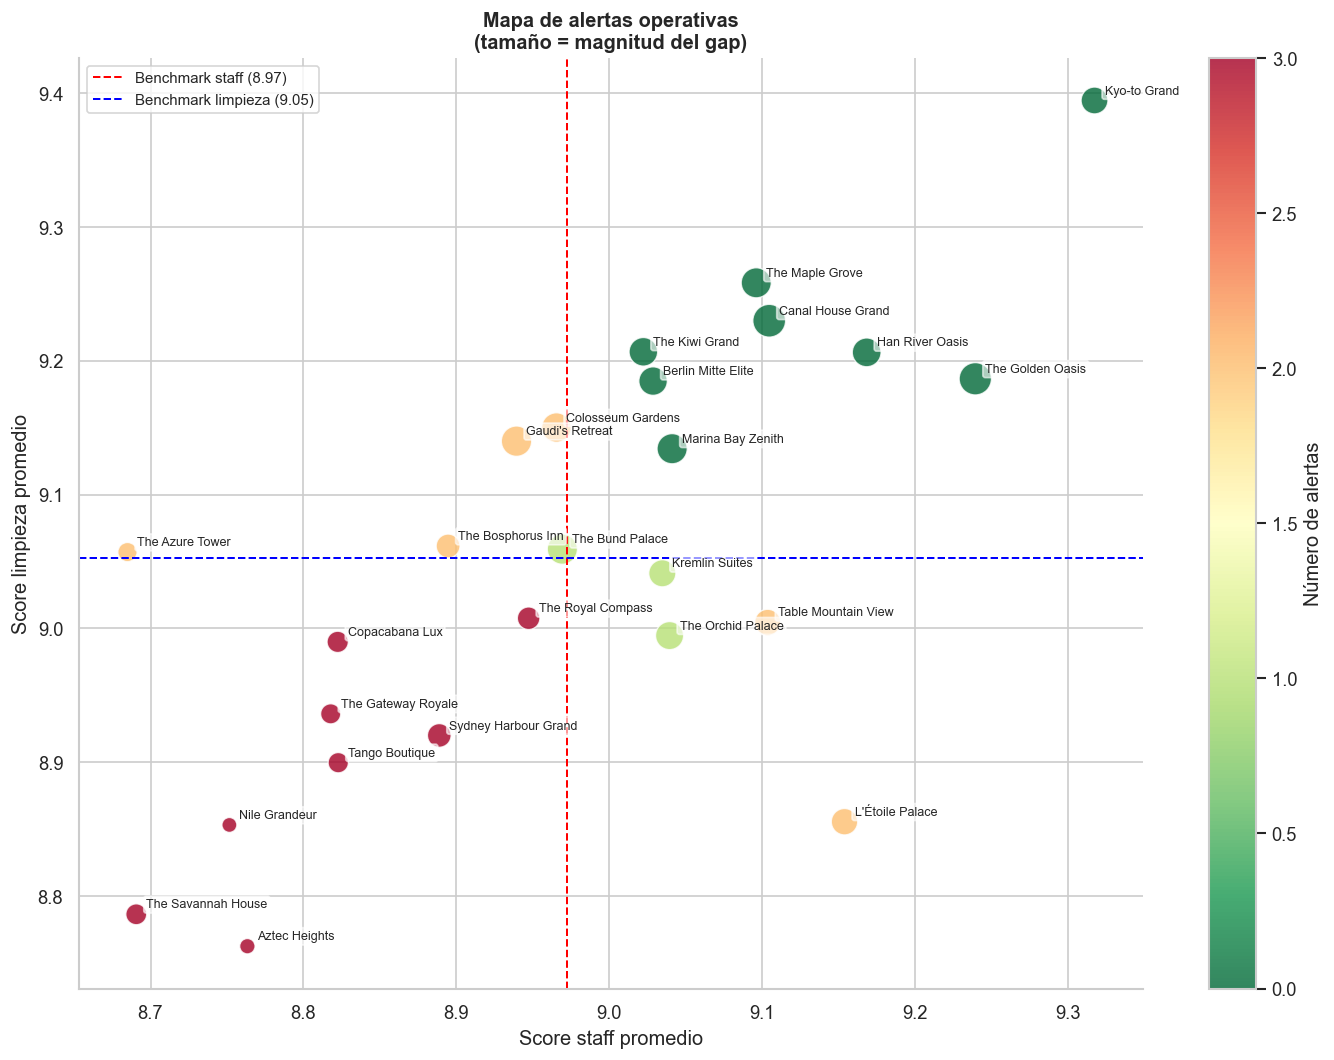

In [51]:
fig, ax = plt.subplots(figsize=(12, 9))

scatter = ax.scatter(
    hotel_scores['score_staff'],
    hotel_scores['score_cleanliness'],
    c=hotel_scores['n_alertas'],
    cmap='RdYlGn_r',
    s=hotel_scores['gap_overall'].abs() * 2000 + 80,
    alpha=0.8, edgecolors='white', linewidths=0.8,
    vmin=0, vmax=3
)

ax.axvline(benchmark['score_staff'], color='red', linestyle='--',
           linewidth=1.2, label=f"Benchmark staff ({benchmark['score_staff']:.2f})")
ax.axhline(benchmark['score_cleanliness'], color='blue', linestyle='--',
           linewidth=1.2, label=f"Benchmark limpieza ({benchmark['score_cleanliness']:.2f})")

# Etiquetas con nombre completo para TODOS los hoteles
for _, row in hotel_scores.iterrows():
    ax.annotate(row['hotel_name'],
                (row['score_staff'], row['score_cleanliness']),
                textcoords='offset points', xytext=(6, 4), 
                fontsize=7.5,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6))

plt.colorbar(scatter, label='Número de alertas')
ax.set_xlabel('Score staff promedio')
ax.set_ylabel('Score limpieza promedio')
ax.set_title('Mapa de alertas operativas\n(tamaño = magnitud del gap)', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Hallazgo 7.2:**
- Los hoteles con 3 alertas simultáneas están concentrados en el cuadrante 

- inferior izquierdo (III) — bajo benchmark en staff Y limpieza.

- Paradoja: algunos hoteles con gap positivo tienen alertas absolutas superan su propia infraestructura pero aún están bajo el estándar de la cadena.

- Conclusión: el problema no es solo relativo (gap) sino absoluto  (nivel de servicio general).

## 8. Conclusiones y Recomendaciones

In [52]:
print("""
╔══════════════════════════════════════════════════════════════╗
║              RESUMEN EJECUTIVO DE HALLAZGOS                 ║
╠══════════════════════════════════════════════════════════════╣
║                                                             ║
║  1. PROBLEMA PRINCIPAL: Facilities (gap −0.174)             ║
║     → Invertir en remodelación antes que capacitación       ║
║                                                             ║
║  2. SEGMENTO CRÍTICO: Business (gap −0.248)                 ║
║     → Value for Money es su mayor queja (−0.752)            ║
║     → Alto valor económico + alto poder de reputación       ║
║                                                             ║
║  3. HOTELES PRIORITARIOS:                                   ║
║     → Canal House Grand  −0.153  (Amsterdam)                ║
║     → The Golden Oasis   −0.148  (Dubai)                    ║
║                                                             ║
║  4. BENCHMARK INTERNO:                                      ║
║     → The Savannah House +0.038 ← replicar su modelo        ║
║                                                             ║
║  5. 17 de 25 hoteles bajo benchmark (problema sistémico)    ║
║     → Intervención a nivel corporativo necesaria            ║
║                                                             ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║              RESUMEN EJECUTIVO DE HALLAZGOS                 ║
╠══════════════════════════════════════════════════════════════╣
║                                                             ║
║  1. PROBLEMA PRINCIPAL: Facilities (gap −0.174)             ║
║     → Invertir en remodelación antes que capacitación       ║
║                                                             ║
║  2. SEGMENTO CRÍTICO: Business (gap −0.248)                 ║
║     → Value for Money es su mayor queja (−0.752)            ║
║     → Alto valor económico + alto poder de reputación       ║
║                                                             ║
║  3. HOTELES PRIORITARIOS:                                   ║
║     → Canal House Grand  −0.153  (Amsterdam)                ║
║     → The Golden Oasis   −0.148  (Dubai)                    ║
║                                                             ║
║  4. BENCHMARK INTERNO:             

In [ ]:
# Exporción tablas limpias a Excel
with pd.ExcelWriter('C:/Users/alicecarballo/OneDrive/PENDIENTES/datos_limpios_powerbi.xlsx') as writer:
    reviews.to_excel(writer, sheet_name='reviews', index=False)
    users.to_excel(writer, sheet_name='users', index=False)
    hotels.to_excel(writer, sheet_name='hotels', index=False)

print(" Archivo exportado listo para Power BI")

 Archivo exportado listo para Power BI
